# 03 — Model Training

**400 тикеров** с макро + FinBERT 32d + financial tables + alt data.

**Требования:** Colab Pro (A100, 50GB RAM)

In [ ]:
!pip install -q pytorch-forecasting==1.1.1 lightning numpy==1.26.4 pandas==2.1.4

from google.colab import drive
drive.mount('/content/drive')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 126.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 54.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
xarray 2025.12.0 requires pandas>=2.2, but you have pandas 2.1.4 which is incompatible.
pl

In [ ]:
MODEL_DIR = '/content/drive/MyDrive/predictamarket/models'
import os
ckpts = sorted([f for f in os.listdir(MODEL_DIR) if f.endswith('.ckpt')])
print('Checkpoints on Drive:')
for c in ckpts:
    size = os.path.getsize(os.path.join(MODEL_DIR, c)) / 1e6
    print(f'  {c}: {size:.0f} MB')


Checkpoints on Drive:


In [ ]:
import os
MODEL_DIR = '/content/drive/MyDrive/predictamarket/models'
for f in os.listdir(MODEL_DIR):
    if f.endswith('.ckpt'):
        os.remove(os.path.join(MODEL_DIR, f))
        print(f'Deleted: {f}')
print('All checkpoints deleted. Ready for fresh training.')


All checkpoints deleted. Ready for fresh training.


In [ ]:
import os
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
torch.set_float32_matmul_precision('medium')

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

DRIVE_DATA = '/content/drive/MyDrive/predictamarket/data'
MODEL_DIR = '/content/drive/MyDrive/predictamarket/models'
os.makedirs(MODEL_DIR, exist_ok=True)

print(f'PyTorch: {torch.__version__}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.0f} GB' if torch.cuda.is_available() else '')

PyTorch: 2.10.0+cu128
GPU: NVIDIA A100-SXM4-40GB
GPU Memory: 42 GB


In [ ]:
# Load config and data
with open(os.path.join(DRIVE_DATA, 'config.json')) as f:
    config = json.load(f)

print('Loading train/val data...')
train_df = pd.read_parquet(os.path.join(DRIVE_DATA, 'train.parquet'))
val_df = pd.read_parquet(os.path.join(DRIVE_DATA, 'val.parquet'))

# Ensure dtypes
for col in config['static_categoricals'] + config['time_varying_known_categoricals']:
    train_df[col] = train_df[col].astype(str)
    val_df[col] = val_df[col].astype(str)
train_df['time_idx'] = train_df['time_idx'].astype(int)
val_df['time_idx'] = val_df['time_idx'].astype(int)

numeric_cols = config['time_varying_unknown_reals']
train_df[numeric_cols] = train_df[numeric_cols].fillna(0.0)
val_df[numeric_cols] = val_df[numeric_cols].fillna(0.0)

print(f'Train: {train_df.shape}, Tickers: {train_df["ticker"].nunique()}')
print(f'Val: {val_df.shape}, Tickers: {val_df["ticker"].nunique()}')
print(f'Features: {len(numeric_cols)}')

Loading train/val data...
Train: (2316737, 115), Tickers: 400
Val: (34800, 115), Tickers: 400
Features: 107


## Create TimeSeriesDataSet

In [ ]:
max_encoder_length = 60
max_prediction_length = config['max_prediction_length']

# Multi-target: Close + Volume
targets = ['Close', 'Volume']
# Check if Volume is in the unknown reals
unknown_reals = config['time_varying_unknown_reals'].copy()
for t in targets:
    if t not in unknown_reals:
        unknown_reals.append(t)

print(f'Tickers: {train_df["ticker"].nunique()}, Train: {len(train_df):,} rows')

# Clean non-finite values in target and features
for df in [train_df, val_df]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=['Close'], inplace=True)
    df.drop(df[df['Close'] <= 0].index, inplace=True)
    numeric = df.select_dtypes(include=[np.number]).columns
    df[numeric] = df[numeric].fillna(0.0)

# Ensure val only has tickers that exist in train
train_tickers = set(train_df['ticker'].unique())
val_df = val_df[val_df['ticker'].isin(train_tickers)].copy()

# Align columns: val must have same columns as train
for col in train_df.columns:
    if col not in val_df.columns:
        val_df[col] = 0.0
val_df = val_df[train_df.columns]

print(f'After cleaning — Train: {train_df.shape}, Val: {val_df.shape}')
print(f'Tickers — Train: {train_df["ticker"].nunique()}, Val: {val_df["ticker"].nunique()}')

training = TimeSeriesDataSet(
    train_df,
    time_idx='time_idx',
    target='Close',  # primary target
    group_ids=config['group_ids'],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=config['static_categoricals'],
    time_varying_known_categoricals=config['time_varying_known_categoricals'],
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=GroupNormalizer(groups=['ticker'], transformation='softplus'),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

train_tail = train_df.groupby('ticker').tail(max_encoder_length)
val_with_history = pd.concat([train_tail, val_df], ignore_index=True)
val_with_history = val_with_history.drop_duplicates(subset=['ticker', 'time_idx']).sort_values(['ticker', 'time_idx']).reset_index(drop=True)
print(f'Val with history: {val_with_history.shape}')

validation = TimeSeriesDataSet.from_dataset(training, val_with_history, predict=True, stop_randomization=True)

batch_size = 128  # sweet spot for A100 with 500 tickers
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=8, persistent_workers=True)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=8, persistent_workers=True)

print(f'Training samples: {len(training)}')
print(f'Validation samples: {len(validation)}')
print(f'Encoder length: {max_encoder_length} (6 months)')
print(f'Prediction length: {max_prediction_length}')
print(f'Batch size: {batch_size}')

Tickers: 400, Train: 2,316,737 rows
After cleaning — Train: (2316737, 115), Val: (34800, 115)
Tickers — Train: 400, Val: 400
Val with history: (58800, 115)
Training samples: 2284337
Validation samples: 400
Encoder length: 60 (6 months)
Prediction length: 22
Batch size: 128


## Define TFT

In [ ]:
import torch._dynamo
torch._dynamo.config.capture_scalar_outputs = True

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=3e-4,
    hidden_size=256,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=128,
    output_size=7,
    loss=QuantileLoss(),
    log_interval=-1,
    reduce_on_plateau_patience=4,
)

print(f'Model parameters: {tft.size() / 1e6:.2f}M')
print(f'Hidden size: 256, Attention heads: 4, Continuous: 128')

param_bytes = sum(p.numel() * p.element_size() for p in tft.parameters())
print(f'Model weights: {param_bytes / 1e6:.1f} MB')
print(f'Estimated VRAM (with batch): ~{param_bytes / 1e6 * 4:.0f} MB (well within A100 40GB)')

Model parameters: 16.27M
Hidden size: 256, Attention heads: 4, Continuous: 128
Model weights: 65.1 MB
Estimated VRAM (with batch): ~260 MB (well within A100 40GB)


## Training

In [ ]:
import torch
if not hasattr(torch.load, '_patched'):
    _original_torch_load = torch.load
    def _patched_torch_load(*args, **kwargs):
        kwargs['weights_only'] = False
        return _original_torch_load(*args, **kwargs)
    _patched_torch_load._patched = True
    torch.load = _patched_torch_load
print('torch.load patched: weights_only=False')


torch.load patched: weights_only=False


In [ ]:
import lightning.pytorch as pl
pl.seed_everything(42)

early_stop = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=5, verbose=True, mode='min')
lr_monitor = LearningRateMonitor(logging_interval='epoch')
checkpoint = ModelCheckpoint(
    dirpath=MODEL_DIR,
    filename='tft-{epoch:02d}-{val_loss:.4f}',
    monitor='val_loss', mode='min', save_top_k=-1, verbose=True
)

trainer = pl.Trainer(
    max_epochs=100,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    gradient_clip_val=0.1,
    limit_train_batches=0.5,
    callbacks=[early_stop, lr_monitor, checkpoint],
    enable_progress_bar=True,
    log_every_n_steps=50,
    accumulate_grad_batches=1,
)

print(f'save_top_k=-1: ALL checkpoints will be saved')
print('Starting training from scratch...')
trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

print(f'\nBest model: {checkpoint.best_model_path}')
print(f'Best val_loss: {checkpoint.best_model_score:.4f}')


INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


save_top_k=-1: ALL checkpoints will be saved
Starting training from scratch...


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │ 18.6 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │ 28.7 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  305 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 12.6 M │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  103 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  263 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  263 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  263 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  263 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  526 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  526 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  131 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    512 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  329 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  164 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  132 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  263 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  132 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │  1.8 K │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 16.3 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 16.3 M                                                                                               
Total estimated model params size (MB): 65                                                                         
Modules in train mode: 1883                                                                                        
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: Metric val_loss improved. New best score: 8.974
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 8.974
INFO: Epoch 0, global step 8923: 'val_loss' reached 8.97361 (best 8.97361), saving model to '/content/drive/MyDrive/predictamarket/models/tft-epoch=00-val_loss=8.9736.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 8923: 'val_loss' reached 8.97361 (best 8.97361), saving model to '/content/drive/MyDrive/predictamarket/models/tft-epoch=00-val_loss=8.9736.ckpt' as top 1
INFO: Metric val_loss improved by 1.649 >= min_delta = 0.0001. New best score: 7.325
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 1.649 >= min_delta = 0.0001. New best score: 7.325
INFO: Epoch 1, global step 17846: 'val_loss' reached 7.32495 (best 7.32495), saving model to '/content/drive/MyDrive/predictamarket/models/tft-epoch=01-val_loss=7.3249.ckpt' as top 2
INFO:lightning.pytorch.utilities.rank_zero:Epoch 1, gl


Best model: /content/drive/MyDrive/predictamarket/models/tft-epoch=01-val_loss=7.3249.ckpt
Best val_loss: 7.3249


## Save artifacts

In [ ]:
with open(os.path.join(MODEL_DIR, 'training_dataset_params.pkl'), 'wb') as f:
    pickle.dump(training.get_parameters(), f)

# Copy config alongside model
import shutil
shutil.copy2(os.path.join(DRIVE_DATA, 'config.json'), os.path.join(MODEL_DIR, 'config.json'))

print('Artifacts saved to Drive:')
for f in os.listdir(MODEL_DIR):
    size = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1e6
    print(f'  {f}: {size:.1f} MB')

Artifacts saved to Drive:
  training_dataset_params.pkl: 0.1 MB
  sanity_check.png: 0.1 MB
  variable_importance.png: 0.0 MB
  config.json: 0.0 MB
  tft-epoch=00-val_loss=8.9736.ckpt: 197.6 MB
  tft-epoch=01-val_loss=7.3249.ckpt: 197.6 MB
  tft-epoch=02-val_loss=8.8051.ckpt: 197.6 MB
  tft-epoch=03-val_loss=8.2107.ckpt: 197.6 MB
  tft-epoch=04-val_loss=9.2586.ckpt: 197.6 MB
  tft-epoch=05-val_loss=9.3008.ckpt: 197.6 MB
  tft-epoch=06-val_loss=9.4489.ckpt: 197.6 MB


## Sanity Check

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

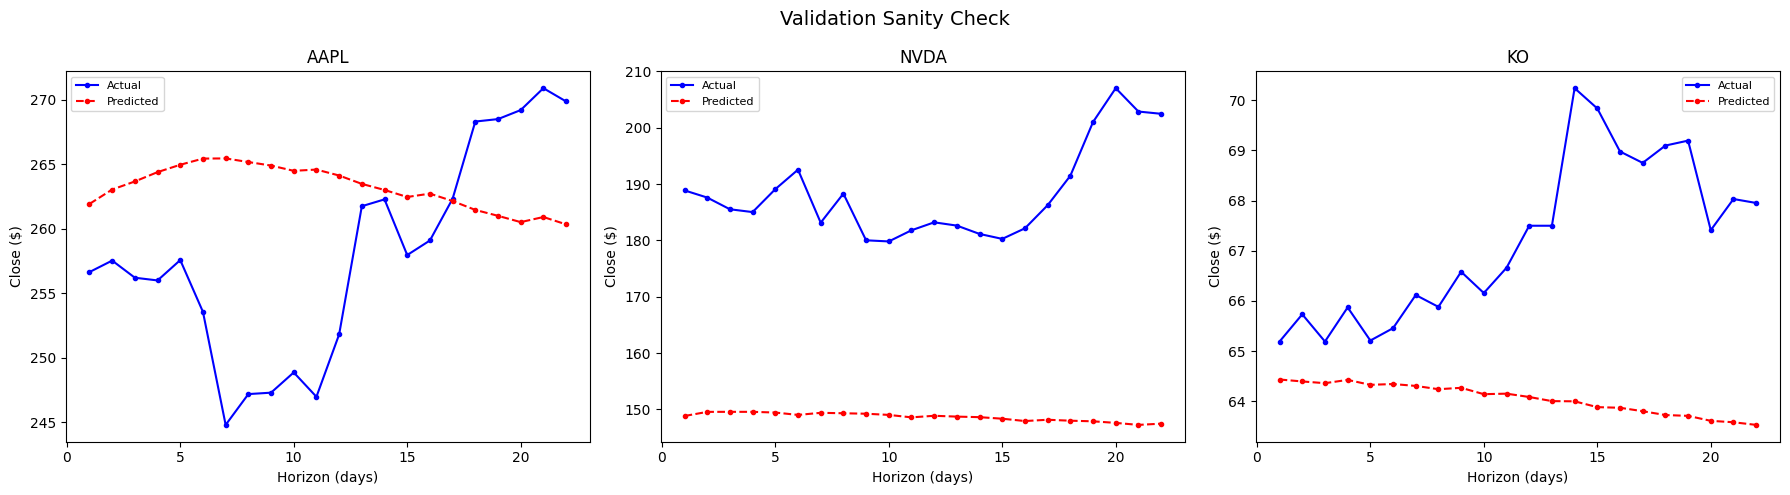

In [ ]:
best_model = TemporalFusionTransformer.load_from_checkpoint(
    checkpoint.best_model_path, map_location='cuda'
)
predictions = best_model.predict(val_dataloader, return_x=True, return_index=True)
actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])

plot_tickers = ['aapl', 'nvda', 'ko']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ticker in zip(axes, plot_tickers):
    ticker_mask = predictions.index['ticker'] == ticker
    if ticker_mask.sum() == 0:
        ax.set_title(f'{ticker.upper()} — no data')
        continue
    last_idx = ticker_mask.values.nonzero()[0][-1]
    pred = predictions.output[last_idx].detach().cpu().numpy()
    actual = actuals[last_idx].detach().cpu().numpy()
    steps = range(1, len(pred) + 1)
    ax.plot(steps, actual, 'b-o', label='Actual', ms=3)
    ax.plot(steps, pred, 'r--o', label='Predicted', ms=3)
    ax.set_title(f'{ticker.upper()}')
    ax.set_xlabel('Horizon (days)')
    ax.set_ylabel('Close ($)')
    ax.legend(fontsize=8)

plt.suptitle('Validation Sanity Check', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'sanity_check.png'), dpi=100)
plt.show()

## Variable importance

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

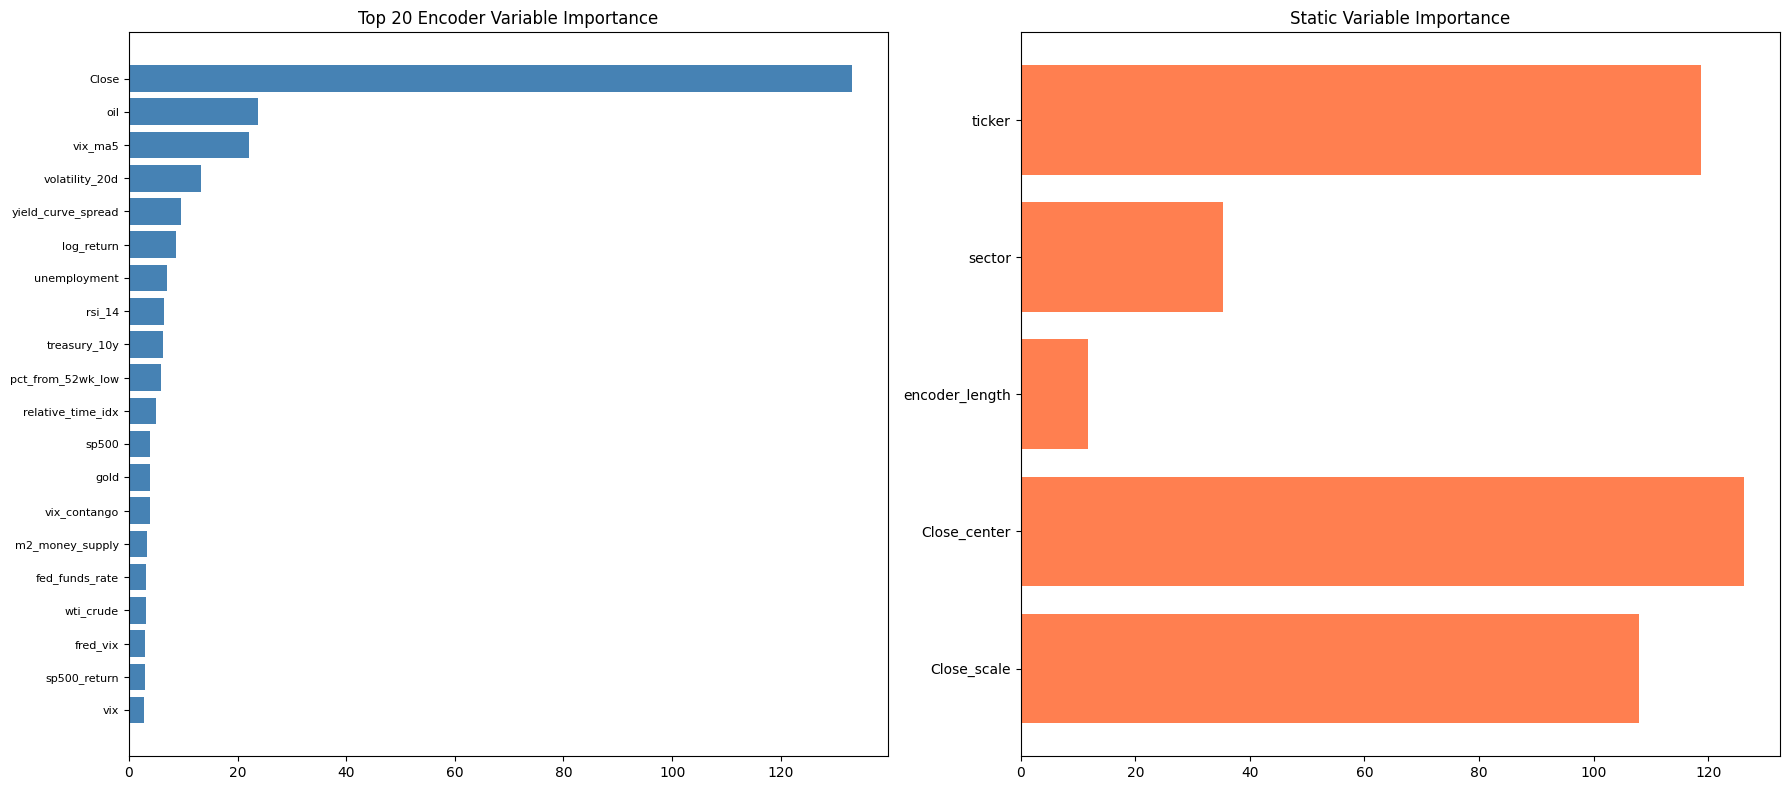


=== Training Complete ===
Model: /content/drive/MyDrive/predictamarket/models/tft-epoch=01-val_loss=7.3249.ckpt
Proceed to 04_model_evaluation.ipynb


In [ ]:
raw_output = best_model.predict(val_dataloader, mode='raw')
interpretation = best_model.interpret_output(raw_output, reduction='mean')


fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax = axes[0]
enc_imp = interpretation['encoder_variables']
top_idx = enc_imp.argsort(descending=True)[:20]
names = [best_model.encoder_variables[i] for i in top_idx]
values = enc_imp[top_idx].detach().cpu().numpy()
ax.barh(range(len(names)), values, color='steelblue')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.set_title('Top 20 Encoder Variable Importance')
ax.invert_yaxis()

ax = axes[1]
static_imp = interpretation.get('static_variables')
if static_imp is not None:
    names_s = best_model.static_variables
    vals_s = static_imp.detach().cpu().numpy()
    ax.barh(range(len(names_s)), vals_s, color='coral')
    ax.set_yticks(range(len(names_s)))
    ax.set_yticklabels(names_s)
    ax.set_title('Static Variable Importance')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'variable_importance.png'), dpi=100)
plt.show()

print('\n=== Training Complete ===')
print(f'Model: {checkpoint.best_model_path}')
print('Proceed to 04_model_evaluation.ipynb')